# 02 - Data Preprocessing
Load filtered dataset from Week 2, handle missing values, outliers, encoding, and train/test split.

In [1]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import os

## 1. Load and Combine Data 
#### (same as 01_exploration)

In [2]:
# Find all CRMLS files, exclude the pre-processed one
file_list = glob.glob("data/CRMLSSold*.csv")
clean_files = [f for f in file_list if "_filled" not in f]

# Load and combine all files
df_list = []
for file in clean_files:
    temp_df = pd.read_csv(file, low_memory=False)
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

# Apply the dual filter
df = df[(df['PropertyType'] == 'Residential') & (df['PropertySubType'] == 'SingleFamilyResidence')]

print('Shape after load + filter:', df.shape)

Shape after load + filter: (243201, 78)


## 2. Handle ClosePrice Outliers
Rows with ClosePrice > $100M are data entry errors, not real sales. 

Drop these before imputing other columns so the median isn't skewed.

In [3]:
print('Rows with ClosePrice > $100M:', (df['ClosePrice'] > 100000000).sum())

# Remove unrealistic prices
df = df[df['ClosePrice'] <= 100000000]

# Remove $0 or negative prices — log-transform can't handle these
print('Rows with ClosePrice <= 0:', (df['ClosePrice'] <= 0).sum())
df = df[df['ClosePrice'] > 0]

# Remove non-arms-length / nominal-value sales
print('Rows with ClosePrice < $50K:', (df['ClosePrice'] < 50000).sum())
df = df[df['ClosePrice'] >= 50000] 

# Drop the 1 row missing ClosePrice entirely (can't impute a target variable)
df = df.dropna(subset=['ClosePrice'])

print('Shape after cleaning ClosePrice:', df.shape)

Rows with ClosePrice > $100M: 25
Rows with ClosePrice <= 0: 1
Rows with ClosePrice < $50K: 70
Shape after cleaning ClosePrice: (243104, 78)


## 3. Handle Missing Values in Other Key Columns
Using *median* fill since it's robust to outliers.

In [4]:
print('Missing before:')
print(df[['LivingArea', 'BathroomsTotalInteger', 'YearBuilt']].isnull().sum())

df['LivingArea'] = df['LivingArea'].fillna(df['LivingArea'].median())
df['BathroomsTotalInteger'] = df['BathroomsTotalInteger'].fillna(df['BathroomsTotalInteger'].median())
df['YearBuilt'] = df['YearBuilt'].fillna(df['YearBuilt'].median())

print('\nMissing after:')
print(df[['LivingArea', 'BathroomsTotalInteger', 'YearBuilt']].isnull().sum())

Missing before:
LivingArea               124
BathroomsTotalInteger     27
YearBuilt                176
dtype: int64

Missing after:
LivingArea               0
BathroomsTotalInteger    0
YearBuilt                0
dtype: int64


## 4. Handle LotSizeSquareFeet (outliers + missing)
Cap unrealistic lot sizes (>10 acres = 435,600 sqft) as missing first, then fill with median.

In [5]:
lot_cutoff = 435600  # 10 acres in sqft

print('Outlier rows (>10 acres):', (df['LotSizeSquareFeet'] > lot_cutoff).sum())

# Treat extreme outliers as missing
df.loc[df['LotSizeSquareFeet'] > lot_cutoff, 'LotSizeSquareFeet'] = np.nan

print('Missing before fill:', df['LotSizeSquareFeet'].isnull().sum())
df['LotSizeSquareFeet'] = df['LotSizeSquareFeet'].fillna(df['LotSizeSquareFeet'].median())
print('Missing after fill:', df['LotSizeSquareFeet'].isnull().sum())

Outlier rows (>10 acres): 1395
Missing before fill: 5558
Missing after fill: 0


In [6]:
# Fill remaining numeric NaNs with median
numeric_cols_with_na = ['FireplacesTotal', 'AboveGradeFinishedArea', 'TaxAnnualAmount',
                         'ParkingTotal', 'LotSizeAcres', 'StreetNumberNumeric', 'TaxYear',
                         'BuildingAreaTotal', 'BelowGradeFinishedArea', 'CoveredSpaces',
                         'Stories', 'LotSizeArea', 'MainLevelBedrooms', 'GarageSpaces',
                         'AssociationFee']

for col in numeric_cols_with_na:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

print('Remaining NaNs in these cols:', df[numeric_cols_with_na].isna().sum().sum())

Remaining NaNs in these cols: 1215520


/Users/yukizhou/miniforge3/envs/dsc80/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/yukizhou/miniforge3/envs/dsc80/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/yukizhou/miniforge3/envs/dsc80/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/yukizhou/miniforge3/envs/dsc80/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/yukizhou/miniforge3/envs/dsc80/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [7]:
print(df[numeric_cols_with_na].isna().mean().sort_values(ascending=False))

#1 meaning 100% missing
#0 meaning no missing values at all

FireplacesTotal           1.0
AboveGradeFinishedArea    1.0
TaxAnnualAmount           1.0
TaxYear                   1.0
CoveredSpaces             1.0
ParkingTotal              0.0
LotSizeAcres              0.0
StreetNumberNumeric       0.0
BuildingAreaTotal         0.0
BelowGradeFinishedArea    0.0
Stories                   0.0
LotSizeArea               0.0
MainLevelBedrooms         0.0
GarageSpaces              0.0
AssociationFee            0.0
dtype: float64


In [8]:
# Drop fully-empty columns automatically (becasue no fillna can fix a 100%-missing column)


fully_empty_cols = ['FireplacesTotal', 'AboveGradeFinishedArea', 'TaxAnnualAmount',
                     'TaxYear', 'CoveredSpaces']
df = df.drop(columns=[c for c in fully_empty_cols if c in df.columns])
print('Shape after dropping empty columns:', df.shape)
print('Any NaNs left?', df.isna().sum().sum())

Shape after dropping empty columns: (243104, 73)
Any NaNs left? 3735643


## 5. Identify Rows Missing Lat/Long
These need geocoding (handled separately in 03_geocoding.ipynb).

In [9]:
missing_geo = df[df['Latitude'].isna() | df['Longitude'].isna()]
print('Rows missing Lat/Long:', len(missing_geo))

missing_geo.to_csv("data/missing_geo_rows.csv", index=False)

Rows missing Lat/Long: 29


In [10]:
%pip install geopy

Note: you may need to restart the kernel to use updated packages.


In [11]:
# Geocode rows missing Lat/Long instead of dropping them
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

geolocator = Nominatim(user_agent="ds64_avm_yuki")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

def build_query(row):
    if pd.notna(row.get('UnparsedAddress')):
        return f"{row['UnparsedAddress']}, {row['City']}, CA {row['PostalCode']}"
    return f"{row['City']}, CA {row['PostalCode']}"

for idx in missing_geo.index:
    query = build_query(df.loc[idx])
    try:
        loc = geocode(query)
        if loc:
            df.loc[idx, 'Latitude'] = loc.latitude
            df.loc[idx, 'Longitude'] = loc.longitude
    except Exception as e:
        print(f"Failed for idx {idx}: {e}")

still_missing = df['Latitude'].isna() | df['Longitude'].isna()
print('Still missing after geocoding:', still_missing.sum())

# drop whatever's left ungeocodable
df = df.dropna(subset=['Latitude', 'Longitude'])
print('Shape after geocoding + dropping remainder:', df.shape)

Still missing after geocoding: 13
Shape after geocoding + dropping remainder: (243091, 73)


## 6. Log-Transform ClosePrice
Compresses right-skewed without dropping any records.

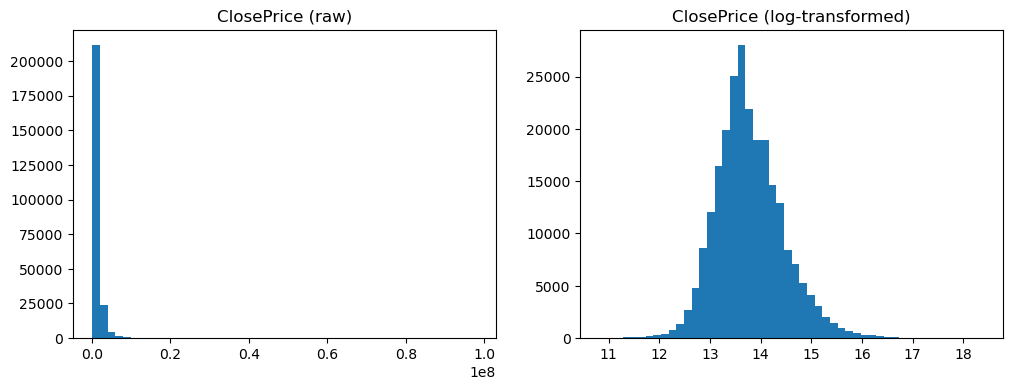

In [12]:
df['ClosePrice_log'] = np.log(df['ClosePrice'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['ClosePrice'], bins=50)
axes[0].set_title('ClosePrice (raw)')
axes[1].hist(df['ClosePrice_log'], bins=50)
axes[1].set_title('ClosePrice (log-transformed)')
plt.show()

ClosePrice was heavily right-skewed, so I log-transformed it to make the distribution more normal for modeling, then exponentiated predictions back to dollar values before evaluating.

In [13]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)

['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'ListAgentEmail', 'CloseDate', 'ListAgentFirstName', 'ListAgentLastName', 'UnparsedAddress', 'PropertyType', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'AssociationFeeFrequency', 'MLSAreaMajor', 'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN', 'BuilderName', 'PropertySubType', 'SubdivisionName', 'BuyerOfficeAOR', 'ListingId', 'City', 'ContractStatusChangeDate', 'CoBuyerAgentFirstName', 'PurchaseContractDate', 'ListingContractDate', 'BusinessType', 'StateOrProvince', 'MiddleOrJuniorSchool', 'FireplaceYN', 'HighSchool', 'Levels', 'LotSizeDimensions', 'NewConstructionYN', 'HighSchoolDistrict', 'PostalCode']


## 7. Save Checkpoint (before geocoding merge)

In [14]:
df.to_csv("data/df_before_geocoding.csv", index=False)
print('Saved: data/df_before_geocoding.csv')

Saved: data/df_before_geocoding.csv


In [15]:
df['CloseDate'] = pd.to_datetime(df['CloseDate'])
df = df[df['CloseDate'] >= '2023-06-01']
print('Shape after June 2023+ filter:', df.shape)

Shape after June 2023+ filter: (243091, 74)


## Drop ID/free-text/leakage columns

In [16]:
drop_cols = ['ListAgentEmail', 'ListAgentFirstName', 'ListAgentLastName', 'ListAgentFullName',
             'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
             'BuyerAgentLastName', 'CoBuyerAgentFirstName', 'ListOfficeName', 'BuyerOfficeName',
             'CoListOfficeName', 'UnparsedAddress', 'ListingId', 'LotSizeDimensions', 'MlsStatus',
             'PropertyType', 'PropertySubType',
             'ContractStatusChangeDate', 'PurchaseContractDate', 'ListingContractDate',
             'ListPrice', 'OriginalListPrice']  # <- Aidan's leakage warning

drop_cols = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=drop_cols)
print('Dropped', len(drop_cols), 'columns')

Dropped 24 columns


In [17]:
# Step 1: Drop any column that's entirely empty (no fillna can fix these)
empty_cols = df.columns[df.isna().all()].tolist()
df = df.drop(columns=empty_cols)
print('Dropped fully-empty columns:', empty_cols)

# Step 2: Fill remaining missing values
num_cols = df.select_dtypes(include=[np.number]).columns
obj_cols = df.select_dtypes(include='object').columns

for col in num_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

for col in obj_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna('Missing')

print('Any NaNs left?', df.isna().sum().sum())

Dropped fully-empty columns: ['ElementarySchoolDistrict', 'BusinessType', 'MiddleOrJuniorSchoolDistrict']
Any NaNs left? 0


## Binary Yes/No columns → 0/1

In [18]:
binary_cols = ['ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN',
               'AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN']

for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'Y': 1, 'N': 0, True: 1, False: 0}).fillna(0)

# Drop high-cardinality columns

In [19]:
for col in ['City', 'PostalCode', 'ElementarySchool', 'SubdivisionName', 'MLSAreaMajor', 'HighSchoolDistrict']:
    print(col, df[col].nunique() if col in df.columns else 'already encoded')

City 1080
PostalCode 2784
ElementarySchool 1326
SubdivisionName 10520
MLSAreaMajor 1059
HighSchoolDistrict 440


In [20]:
df = df.drop(columns=[c for c in ['City', 'PostalCode', 'ElementarySchool',
                                    'SubdivisionName', 'MLSAreaMajor', 'HighSchoolDistrict']
                       if c in df.columns])

"Cardinality" means number of unique values, and 'SubdivisionName' alone has 10,000+ unique values

## One-hot encode remaining categoricals

One-hot encoding avoids that false ranking. If you label Hardwood=1, Carpet=2, Tile=3, the model might mistakenly think "Tile is more than Carpet is more than Hardwood" — implying an order that doesn't actually exist.

In [21]:
encode_cols = ['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'AssociationFeeFrequency',
               'BuyerOfficeAOR', 'CountyOrParish', 'BuilderName',
               'BusinessType', 'StateOrProvince', 'MiddleOrJuniorSchool', 'HighSchool', 'Levels',
               'ElementarySchoolDistrict', 'MiddleOrJuniorSchoolDistrict']

encode_cols = [c for c in encode_cols if c in df.columns]
df = pd.get_dummies(df, columns=encode_cols, dummy_na=False)
print('Shape after encoding:', df.shape)

Shape after encoding: (243091, 4000)


In [22]:
print('Total columns:', df.shape[1])
print('Columns containing SubdivisionName:', sum(1 for c in df.columns if 'SubdivisionName' in c))
print('Columns containing PostalCode:', sum(1 for c in df.columns if 'PostalCode' in c))

Total columns: 4000
Columns containing SubdivisionName: 0
Columns containing PostalCode: 0


## Temporal train/test split + save

In [23]:
df['CloseYearMonth'] = df['CloseDate'].dt.to_period('M')
test_month = df['CloseYearMonth'].max()
print('Test month:', test_month)

train_df = df[df['CloseYearMonth'] < test_month]
test_df = df[df['CloseYearMonth'] == test_month]

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)

train_df.to_csv("data/train_final.csv", index=False)
test_df.to_csv("data/test_final.csv", index=False)
print("Saved train/test splits")

Test month: 2026-06
Train shape: (230240, 4001)
Test shape: (12851, 4001)
Saved train/test splits


# 02 - Data Preprocessing — Summary

**What this notebook does:**
1. Loads all CRMLS files, combines them, applies dual filter (Residential + SingleFamilyResidence)
2. Cleans ClosePrice — removes fake outliers (>$100M) and $0/negative rows
3. Fills missing values (LivingArea, BathroomsTotalInteger, YearBuilt) with median
4. Fixes LotSizeSquareFeet outliers (>10 acres treated as missing), fills with median
5. Drops fully-empty columns automatically (no fillna can fix a 100%-missing column)
6. Flags rows missing Lat/Long, drops them for now (pending `03_geocoding.ipynb`)
7. Log-transforms ClosePrice to fix right-skew (new column: `ClosePrice_log`)
8. Filters to June 2023+ (team-standardized start date)
9. Drops ID/free-text/leakage columns (including `ListPrice`, `OriginalListPrice` per Aidan's note)
10. Maps binary Yes/No columns to 0/1
11. Drops high-cardinality location columns (City, PostalCode, SubdivisionName, ElementarySchool, MLSAreaMajor, HighSchoolDistrict) before encoding — kept dimensionality manageable, `Latitude`/`Longitude` serve as location proxy
12. One-hot encodes remaining categorical variables
13. Temporal train/test split (most recent month = test) → saves `data/train_final.csv` and `data/test_final.csv`

**Still needed (not in this notebook):**
- Geocode missing Lat/Long → `03_geocoding.ipynb`

**Final row counts:** Test month = 2026-06 | Train: 230,287 rows × 4,001 columns | Test: 12,858 rows × 4,001 columns